In [147]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score,confusion_matrix,recall_score,precision_score,accuracy_score,classification_report

# Data Analysis

In [96]:
df=pd.read_csv('loan_approval_dataset.csv')
df.head()

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24 months,Unemployed,Owned,No,No
4,25,28512,788,14528,12 months,Employed,Owned,No,No


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                1000 non-null   int64 
 1   Salary             1000 non-null   int64 
 2   Credit_Score       1000 non-null   int64 
 3   Loan_Amount        1000 non-null   int64 
 4   Loan_Term          1000 non-null   object
 5   Employment_Status  1000 non-null   object
 6   Residence_Type     1000 non-null   object
 7   Previous_Default   1000 non-null   object
 8   Loan_Approved      1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 70.4+ KB


# Data Cleaning

In [98]:
df.duplicated().sum()

0

In [99]:
df.isnull().sum()

Age                  0
Salary               0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Employment_Status    0
Residence_Type       0
Previous_Default     0
Loan_Approved        0
dtype: int64

In [100]:
df.head()

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24 months,Unemployed,Owned,No,No
4,25,28512,788,14528,12 months,Employed,Owned,No,No


In [101]:
num_cal=['Age','Salary','Credit_Score','Loan_Amount']
for col in num_cal:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    outliers=df[(df[col]<lower_bound) | (df[col]>upper_bound)]
    print(f"{col} has {len(outliers)} outliers")

Age has 0 outliers
Salary has 0 outliers
Credit_Score has 0 outliers
Loan_Amount has 0 outliers


<Axes: >

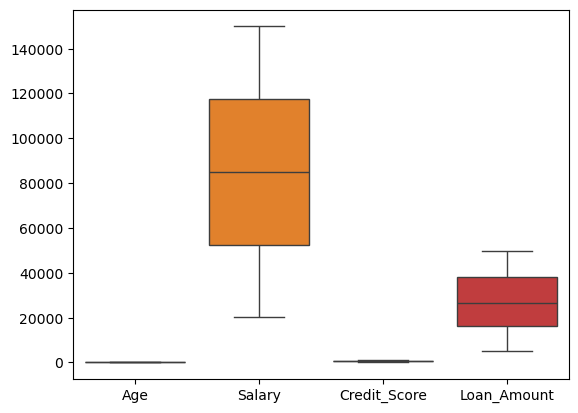

In [102]:
sns.boxplot(data=df[num_cal])

# Preprocessing

In [103]:
x=df.drop('Loan_Approved',axis=1)
y=df['Loan_Approved']

In [104]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [105]:
# obj_col=x.select_dtypes(include='objects').columns

# def col_nunique(cols):
#     for col in cols:
#         print(f'column Name -{col}==>No of unique values-{data[col].nunique}')

In [106]:
df['Loan_Term'].nunique()

4

In [107]:
df['Employment_Status'].nunique()

3

In [108]:
df['Residence_Type'].nunique()

3

In [109]:
df['Previous_Default'].nunique()

2

# Encoding

In [110]:
cat_col=['Employment_Status','Residence_Type','Previous_Default','Loan_Term']

In [111]:
emp_label=OneHotEncoder(dtype=int,sparse_output=False,handle_unknown='ignore')

In [112]:
xtrain_encode=emp_label.fit_transform(xtrain[cat_col])
encoded_xtrain_df=pd.DataFrame(xtrain_encode,columns=emp_label.get_feature_names_out(cat_col),index=xtrain.index)
xtrain=pd.concat([xtrain,encoded_xtrain_df],axis=1)
xtrain.drop(columns=cat_col,inplace=True)

In [113]:
xtest_encode=emp_label.transform(xtest[cat_col])
encoded_xtest_df=pd.DataFrame(xtest_encode,columns=emp_label.get_feature_names_out(cat_col),index=xtest.index)
xtest=pd.concat([xtest,encoded_xtest_df],axis=1)
xtest.drop(columns=cat_col,inplace=True)

In [114]:
df['Loan_Approved'].nunique()

2

In [115]:
ytrain.head()

29      No
535     No
695     No
557     No
836    Yes
Name: Loan_Approved, dtype: object

In [116]:
xtrain.head()

,Age,Salary,Credit_Score,Loan_Amount,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months
29,44,85441,507,17109,0,1,0,0,0,1,1,0,0,1,0,0
535,38,87298,489,10776,1,0,0,1,0,0,1,0,0,0,1,0
695,45,49629,762,39441,1,0,0,1,0,0,1,0,0,0,1,0
557,47,75337,809,40596,1,0,0,1,0,0,0,1,1,0,0,0
836,46,101121,504,31956,0,0,1,1,0,0,1,0,0,0,1,0


# Scaling

In [117]:
scaler=StandardScaler()
scaled_xtrain=scaler.fit_transform(xtrain)

In [118]:
scaled_xtest=scaler.transform(xtest)

In [119]:
xtrain.corr()

,Age,Salary,Credit_Score,Loan_Amount,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months
Age,1.000000,0.041491,-0.027405,0.017820,0.060324,0.023668,-0.082121,-0.096849,0.021086,0.077031,0.024481,-0.024481,0.020413,0.006698,0.003907,-0.031548
Salary,0.041491,1.000000,-0.026146,-0.022052,0.022633,0.017856,-0.039669,-0.033147,0.063970,-0.030943,-0.035479,0.035479,0.082948,-0.044094,-0.041489,0.001365
Credit_Score,-0.027405,-0.026146,1.000000,-0.002800,0.014264,-0.064383,0.049645,-0.027589,0.045489,-0.017923,-0.010338,0.010338,-0.024819,-0.004394,0.038482,-0.008530
Loan_Amount,0.017820,-0.022052,-0.002800,1.000000,0.004037,-0.012601,0.008503,0.026412,0.004943,-0.031805,-0.003898,0.003898,-0.041860,-0.019876,0.052377,0.010750
Employment_Status_Employed,0.060324,0.022633,0.014264,0.004037,1.000000,-0.479995,-0.500422,0.007633,-0.004300,-0.003407,-0.037267,0.037267,0.031990,-0.021678,0.043753,-0.054275
Employment_Status_Self-Employed,0.023668,0.017856,-0.064383,-0.012601,-0.479995,1.000000,-0.519326,0.005004,0.033111,-0.038514,0.023071,-0.023071,0.017179,-0.005053,-0.038280,0.025724
Employment_Status_Unemployed,-0.082121,-0.039669,0.049645,0.008503,-0.500422,-0.519326,1.000000,-0.012374,-0.028489,0.041329,0.013533,-0.013533,-0.048117,0.026104,-0.004843,0.027484
Residence_Type_Mortgage,-0.096849,-0.033147,-0.027589,0.026412,0.007633,0.005004,-0.012374,1.000000,-0.512264,-0.497958,-0.035819,0.035819,-0.025462,-0.017345,0.030152,0.013574
Residence_Type_Owned,0.021086,0.063970,0.045489,0.004943,-0.004300,0.033111,-0.028489,-0.512264,1.000000,-0.489691,0.059943,-0.059943,0.056272,0.040467,-0.065955,-0.032847
Residence_Type_Rented,0.077031,-0.030943,-0.017923,-0.031805,-0.003407,-0.038514,0.041329,-0.497958,-0.489691,1.000000,-0.024163,0.024163,-0.030971,-0.023253,0.035987,0.019386


# Model Training

In [120]:
log_model=LogisticRegression()


In [121]:
log_model.fit(scaled_xtrain,ytrain)

LogisticRegression()

In [122]:
ytrain_pred=log_model.predict(scaled_xtrain)

In [123]:
ytest_pred=log_model.predict(scaled_xtest)

# Model Evaluation

In [124]:
con_xtrain=confusion_matrix(ytrain,ytrain_pred)
con_xtrain

array([[205, 192],
       [171, 232]], dtype=int64)

In [125]:
con_xtest=confusion_matrix(ytest,ytest_pred)
con_xtest

array([[47, 48],
       [52, 53]], dtype=int64)

# Conclusion

1. out of 1000 values, 437 values are correctly predicted.
2. Out of 397 Actual 'Not Approved',only 205 values are correctly predicted as 'Not Approved' and 192 values are wrongly predicted as 'Approved' when it is actually 'Not Approved'.
3. Out of 403 Actual 'Approved',only 232 values are correctly predicted as 'Approved' and 171 values are wrongly predicted as 'Not Approved' when it is actually 'Approved'.

In [126]:
print("xtrain Precision scorce of 'No':",con_xtrain[0,0]/(con_xtrain[0,0]+con_xtrain[1,0]))
print("xtrain Precision scorce of 'No':",con_xtrain[1,1]/(con_xtrain[1,1]+con_xtrain[0,1]))

xtrain Precision scorce of 'No': 0.5452127659574468
xtrain Precision scorce of 'No': 0.5471698113207547


In [127]:
print("Precision Scorce of Train 'No':",precision_score(ytrain,ytrain_pred,pos_label='No'))
print("Precision Scorce of Train 'Yes':",precision_score(ytrain,ytrain_pred,pos_label='Yes')) 

Precision Scorce of Train 'No': 0.5452127659574468
Precision Scorce of Train 'Yes': 0.5471698113207547


In [128]:
print("xtest Precision scorce of 'No':",con_xtest[0,0]/(con_xtest[0,0]+con_xtest[1,0]))
print("xtest Precision scorce of 'No':",con_xtest[1,1]/(con_xtest[1,1]+con_xtest[0,1]))

xtest Precision scorce of 'No': 0.47474747474747475
xtest Precision scorce of 'No': 0.5247524752475248


In [129]:
print("Precision Scorce of Test 'No':",precision_score(ytest,ytest_pred,pos_label='No') )
print("Precision Scorce of Test 'Yes':",precision_score(ytest,ytest_pred,pos_label='Yes') ) 

Precision Scorce of Test 'No': 0.47474747474747475
Precision Scorce of Test 'Yes': 0.5247524752475248


# conclusion

1. Out of all the predicted loan as 'Not Approved',47% of the values are correctly predicted as 'Not Approved' and remaining 53% values are wrongly predicted as 'Not Approved'.
2. Out of all the predicted loan as 'Approved',52% of the values are correctly predicted as 'Approved' and remaining 48% values are wrongly predicted as 'Approved'.

In [130]:
print("xtrain Precision scorce of 'No':",con_xtrain[0,0]/(con_xtrain[0,0]+con_xtrain[0,1]))
print("xtrain Precision scorce of 'No':",con_xtrain[1,1]/(con_xtrain[1,1]+con_xtrain[1,0]))

xtrain Precision scorce of 'No': 0.5163727959697733
xtrain Precision scorce of 'No': 0.575682382133995


In [131]:
print("Recall Scorce of Train 'No':",recall_score(ytrain,ytrain_pred,pos_label='No'))
print("Recall Scorce of Train 'Yes':",recall_score(ytrain,ytrain_pred,pos_label='Yes'))

Recall Scorce of Train 'No': 0.5163727959697733
Recall Scorce of Train 'Yes': 0.575682382133995


In [132]:
print("xtrain Precision scorce of 'No':",con_xtest[0,0]/(con_xtest[0,0]+con_xtest[0,1]))
print("xtrain Precision scorce of 'No':",con_xtest[1,1]/(con_xtest[1,1]+con_xtest[1,0]))

xtrain Precision scorce of 'No': 0.49473684210526314
xtrain Precision scorce of 'No': 0.5047619047619047


In [133]:
print("Recall Scorce of Test 'No':",recall_score(ytest,ytest_pred,pos_label='No'))
print("Recall Scorce of Test 'Yes':",recall_score(ytest,ytest_pred,pos_label='Yes'))

Recall Scorce of Test 'No': 0.49473684210526314
Recall Scorce of Test 'Yes': 0.5047619047619047


* The Precision scorce and Recall Scorce for both train and test data are reasonably close, but with slight drop in test precision.This Indicates Model is Generalized well.

# Conclusion

1. Out of all actual loan 'Not Approved', 49% values are correctly predicted as 'Not Approved' and 51% values are wrongly predicted as 'Approved'.
2. Out of all actual loan 'Approved', 50% values are correctly predicted as 'Approved' and 50% values are wrongly predicted as 'Not Approved'.

In [134]:
ytrain.value_counts()

Loan_Approved
Yes    403
No     397
Name: count, dtype: int64

In [145]:
ytest.value_counts()

Loan_Approved
Yes    105
No      95
Name: count, dtype: int64

In [136]:
# ytrain['Yes'].value_counts()

In [146]:
print("Accuracy scorce of Train:",((con_xtrain[0,0]+con_xtrain[1,1])/(397+403)))
print("Accuracy scorce of Train:",((con_xtest[0,0]+con_xtest[1,1])/(105+95)))

Accuracy scorce of Train: 0.54625
Accuracy scorce of Train: 0.5


In [ ]:
print("Accuary Scorce of Train:",accuracy_score(ytrain,ytrain_pred))
print("Accuary Scorce of Test:",accuracy_score(ytest,ytest_pred))

Accuary Scorce of Train: 0.54625
Accuary Scorce of Test: 0.5


# Conclusion

1. On the training dataset, approximately 54% of the samples are correctly classified, while around 46% are misclassified.
2. On the testing dataset, approximately 50% of the samples are correctly classified, while around 50% are misclassified.

In [ ]:
print("F1 Scorce of Train 'No':",f1_score(ytrain,ytrain_pred,pos_label='No'))
print("F1 Scorce of Train 'Yes':",f1_score(ytrain,ytrain_pred,pos_label='Yes'))

F1 Scorce of Train 'No': 0.5304010349288486
F1 Scorce of Train 'Yes': 0.5610640870616687


In [ ]:
print("F1 Scorce of Test 'No':",f1_score(ytest,ytest_pred,pos_label='No'))
print("F1 Scorce of Test 'Yes':",f1_score(ytest,ytest_pred,pos_label='Yes'))
# overall (avg=yes+no/2)

F1 Scorce of Test 'No': 0.4845360824742268
F1 Scorce of Test 'Yes': 0.5145631067961165


# Conclusion

1. On Training dataset, F1 Scorce achieves 53% for 'Not Approved' and 56% for 'Approved',showing a reasonable balance between prescision and recall.
2. On Testing dataset, F1 Scorce achieves 48% for 'Not Approved' and 51% for 'Approved',reflecting reduced performance on unseen data.

In [ ]:
# model.scorce=accuary in classification
print("Overall Train Performance ",log_model.score(scaled_xtrain,ytrain))
print("Overall Test Performance ",log_model.score(scaled_xtest,ytest))

Overall Train Performance  0.54625
Overall Test Performance  0.5


# Conclusion

1. out of 800 samples, only 56% values are correctly predicted for training data.
2. out of 800 samples, only 50% values are correctly predicted for testing data.
3. This means model performance is not good.

In [150]:
print(classification_report(ytrain,ytrain_pred))

              precision    recall  f1-score   support

          No       0.55      0.52      0.53       397
         Yes       0.55      0.58      0.56       403

    accuracy                           0.55       800
   macro avg       0.55      0.55      0.55       800
weighted avg       0.55      0.55      0.55       800

